# Detailed Implementation of Principal Component Analysis

Importing Libraries 

In [1]:
import math
import numpy as np
import random

Input

$$
D=\{x_1,x_2,\ldots,x_n\}, \qquad x_i \in \mathbb{R}^{N}
$$

Step 1: Compute Mean

$$
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

Step 2: Compute Covariance Matrix

$$
S=\frac{1}{n}(D-\mu)(D-\mu)^T
$$

Step 3: Compute Eigenvalues and Eigenvectors

$$
Sv=\lambda v
$$

Step 4: Form Projection Matrix

$$
A=[v_1\;v_2\;\cdots\;v_M]^T,\qquad A\in\mathbb{R}^{M\times N}
$$

Step 5: Reduce Dimension

$$
y=Ax
$$

where

$$
x\in\mathbb{R}^{N},\qquad
y\in\mathbb{R}^{M},\qquad
M<N
$$

Dimention of Data

In [34]:
N = 10
M = 5
v = []
for i in range(0,N):
    v.append(round(random.uniform(-1,1),4))

Showing the generated data

In [46]:
v

[0.6967,
 0.785,
 -0.8712,
 0.8904,
 -0.8673,
 -0.5921,
 -0.4936,
 0.5787,
 0.0348,
 -0.6917]

Finding Covarience 

In [35]:
mean = np.mean(v)

In [36]:
xb = []
for i in v:
    xb.append(i-mean)
xb = np.array(xb)

In [37]:
xb = np.array(xb).reshape(N, 1)

In [38]:
conv = xb.T

In [39]:
conv = xb @ conv

In [40]:
conv = conv/ (1/N)

In [41]:
conv

array([[ 5.62095073,  6.28296232, -6.13406594,  7.07317774, -6.10482647,
        -4.04156951, -3.30308546,  4.73626933,  0.65848786, -4.78830059],
       [ 6.28296232,  7.02294281, -6.85651005,  7.90622643, -6.82382688,
        -4.51756832, -3.69210877,  5.29408692,  0.73604175, -5.3522462 ],
       [-6.13406594, -6.85651005,  6.69402149, -7.71886123,  6.66211286,
         4.41050902,  3.60461157, -5.16862534, -0.71859871,  5.22540634],
       [ 7.07317774,  7.90622643, -7.71886123,  8.90060165, -7.68206746,
        -5.0857481 , -4.15646955,  5.95993034,  0.82861457, -6.02540438],
       [-6.10482647, -6.82382688,  6.66211286, -7.68206746,  6.63035633,
         4.38948529,  3.58742934, -5.14398787, -0.71517334,  5.20049821],
       [-4.04156951, -4.51756832,  4.41050902, -5.0857481 ,  4.38948529,
         2.90596465,  2.3749807 , -3.40546691, -0.47346518,  3.44287837],
       [-3.30308546, -3.69210877,  3.60461157, -4.15646955,  3.58742934,
         2.3749807 ,  1.94101925, -2.78321286

Finding Eigen Values and Vectors 

In [42]:
eigenvalues, eigenvectors = np.linalg.eigh(conv)

In [43]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Taking Top prority vectors

In [44]:
principal_components = eigenvectors[:, :M]

Reduced from Original Data

In [45]:
X_reduced = v @ principal_components

print("\nReduced Data:")
print(X_reduced)

print("\nPrincipal Components:")
print(principal_components)

print("\nEigenvalues:")
print(eigenvalues[:M])


Reduced Data:
[ 2.18775729  0.05096025  0.01055407 -0.08639525 -0.01764029]

Principal Components:
[[ 3.42693407e-01  1.96689329e-01 -8.44371122e-02 -8.33606385e-02
   3.62270618e-02]
 [ 3.83054374e-01 -8.09734603e-01 -3.84652463e-04  6.70350126e-02
  -2.18484421e-02]
 [-3.73976585e-01  2.18535520e-01 -2.81481005e-01  3.38843283e-02
  -4.70575617e-02]
 [ 4.31231565e-01  1.54521412e-01  2.88602274e-01  1.61643748e-01
  -8.85977492e-02]
 [-3.72193937e-01 -1.05251656e-01  1.92659281e-01  5.64749505e-01
  -2.13615787e-02]
 [-2.46403018e-01 -3.76407949e-01 -5.14867331e-01 -2.61954043e-01
   2.11963339e-02]
 [-2.01379743e-01 -1.36645783e-01  5.67953891e-01 -5.51439484e-02
  -2.06323845e-01]
 [ 2.88756894e-01  1.17458825e-01 -4.49597217e-01  6.24808798e-01
  -2.52288752e-01]
 [ 4.01461352e-02  7.23197185e-04  3.76280517e-02  2.06506511e-01
   9.38278925e-01]
 [-2.91929092e-01 -2.20858589e-01  4.49030099e-02  3.71007695e-01
  -2.55770242e-02]]

Eigenvalues:
[4.78628196e+01 3.29391579e-15 9.18

___

# PCA using Scikit learn on External Dataset

In [50]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("Iris.csv")

# Display first 5 rows
print(df.head())

# Separate features and labels
X = df.iloc[:, :-1]   # All columns except the last
y = df.iloc[:, -1]    # Last column (species)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Species"] = y

print("\nReduced Dataset:")
print(pca_df)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPrincipal Components:")
print(pca.components_)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Reduced Dataset:
          PC1       PC2         Species
0   -2.816339  0.506051     Iris-setosa
1   -2.645527 -0.651799     Iris-setosa
2   -2.879481 -0.321036     Iris-setosa
3   -2.810934 -0.577363     Iris-setosa
4   -2.879884  0.670468     Iris-setosa
..        ...       ...             ...
145  2.424421  0.377119  Iris-virginica
146  2.164220 -0.915696  Iris-virginica
147  2.139796  0.254272  Iris-virginica
148  2.029480  0.998725  Iris-virginica
149  1.674835 -0.046213  Iris-virginica

[150 rows x 3 columns]

Explained Varia

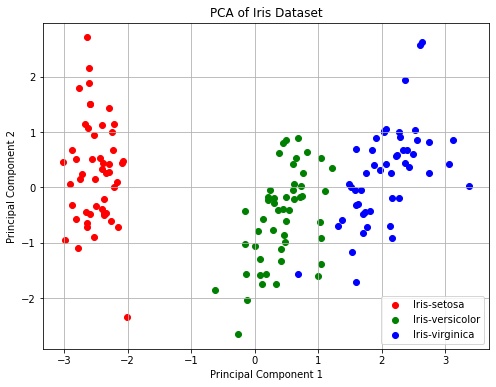

In [51]:
import matplotlib.pyplot as plt

colors = {
    "Iris-setosa": "red",
    "Iris-versicolor": "green",
    "Iris-virginica": "blue"
}

plt.figure(figsize=(8,6))

for species in pca_df["Species"].unique():
    subset = pca_df[pca_df["Species"] == species]
    plt.scatter(subset["PC1"], subset["PC2"],
                label=species,
                color=colors.get(species, None))

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()